# EGC5310 — Estruturas de Dados
## Semana 04 — Notebook do Estudante

**Tema:** busca sequencial, busca binária e custo de organização  
**Regra da semana:** registre a previsão antes de executar.


## Orientação

Este notebook alterna três ações:

> **prever → executar → interpretar**

Não apague sua previsão quando encontrar um resultado diferente. O contraste é parte da aprendizagem.


# Atividade 1 — Quais posições serão examinadas?

Considere a coleção ordenada abaixo, com 31 matrículas. Procure inicialmente o alvo `270`.

Sem executar código, preencha a tabela.


In [ ]:
matriculas = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310]
alvo = 270
len(matriculas)


| passo | `inicio` | `fim` | `meio` | valor no meio | decisão/região descartada |
|---:|---:|---:|---:|---:|---|
| 1 | 0 | 30 |  |  |  |
| 2 |  |  |  |  |  |
| 3 |  |  |  |  |  |
| 4 |  |  |  |  |  |
| 5 |  |  |  |  |  |

**Minha previsão para a sequência de índices:**  
> Escreva aqui.

**Número previsto de comparações:**  
> Escreva aqui.


## 1.1 Confira sua previsão

Execute a função somente após preencher a tabela.


In [ ]:
def busca_binaria_detalhada(dados, alvo):
    inicio, fim = 0, len(dados) - 1
    caminho = []
    while inicio <= fim:
        meio = (inicio + fim) // 2
        caminho.append({"inicio": inicio, "fim": fim, "meio": meio, "valor": dados[meio]})
        if dados[meio] == alvo:
            return meio, caminho
        if dados[meio] < alvo:
            inicio = meio + 1
        else:
            fim = meio - 1
    return -1, caminho

indice, caminho = busca_binaria_detalhada(matriculas, alvo)
indice, caminho


### Interpretação

1. Sua sequência coincidiu com a execução?  
   > Escreva aqui.
2. Em qual passo ocorreu o maior descarte?  
   > Escreva aqui.
3. Por que os valores descartados não precisam ser examinados?  
   > Escreva aqui.


## 1.2 Alvo inexistente

Agora use `alvo = 275`.

Antes de executar, responda: como o algoritmo percebe que o elemento não existe?

> Escreva aqui.


In [ ]:
alvo = 275
busca_binaria_detalhada(matriculas, alvo)


# Atividade 2 — Complete a implementação

Complete os três `TODO`s sem consultar a versão pronta.


In [16]:
def busca_binaria(dados, alvo, inicio=0, fim=None):

    if fim == None:
        fim = len(dados) - 1
    posicao = None

    while inicio <= fim:
        meio = (inicio + fim) // 2
        valor = dados[meio]
        posicao = meio

        if valor == alvo:
            # TODO 1: o que deve ser devolvido?
            return posicao
        elif valor < alvo:
            # TODO 2: atualize o limite correto
            inicio = meio + 1
            return busca_binaria(dados, alvo, inicio, fim)
        else:
            # TODO 3: atualize o limite correto
            fim = meio - 1
            return busca_binaria(dados, alvo, inicio, fim)

    return -1


In [17]:
# Testes mínimos: todos devem passar depois de completar a função.
print(busca_binaria([10, 20, 30, 40, 50], 10))
print(busca_binaria([10, 20, 30, 40, 50], 30))
print(busca_binaria([10, 20, 30, 40, 50], 50))
print(busca_binaria([10, 20, 30, 40, 50], 35))
print(busca_binaria([], 35))
print("Testes concluídos.")


0
2
4
-1
-1
Testes concluídos.


## 2.1 Explique as atualizações

Por que usamos `meio + 1` e `meio - 1`, em vez de apenas `meio`?

> Escreva aqui.


# Atividade 3 — A pré-condição

Considere:

```python
dados = [10, 20, 80, 30, 40, 50, 60, 70]
```

Antes de executar:

1. `80` existe?  
   > Escreva aqui.
2. A busca binária está autorizada a descartar metades nessa coleção?  
   > Escreva aqui.
3. O resultado da função é confiável? Por quê?  
   > Escreva aqui.


In [ ]:
dados_desordenados = [10, 20, 80, 30, 40, 50, 60, 70]
80 in dados_desordenados, busca_binaria_detalhada(dados_desordenados, 80)


# Atividade 4 — Um milhão de registros

Preencha antes do benchmark. Use uma estimativa para a busca binária.

| `n` | diferença esperada | sequencial — pior caso | binária — estimativa |
|---:|---|---:|---:|
| 100 |  |  |  |
| 1.000 |  |  |  |
| 10.000 |  |  |  |
| 100.000 |  |  |  |
| 1.000.000 |  |  |  |

**Minha hipótese sobre o formato das curvas:**  
> Escreva aqui.


In [ ]:
import math
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    print(n, math.ceil(math.log2(n + 1)))


# Atividade 5 — Benchmark

O tempo será medido, mas a contagem de comparações é a principal evidência estrutural.


In [18]:
import time
import statistics
import pandas as pd
import matplotlib.pyplot as plt

def busca_sequencial_contada(dados, alvo):
    comparacoes = 0
    for i, valor in enumerate(dados):
        comparacoes += 1
        if valor == alvo:
            return i, comparacoes
    return -1, comparacoes

def busca_binaria_contada(dados, alvo):
    inicio, fim, comparacoes = 0, len(dados) - 1, 0
    while inicio <= fim:
        meio = (inicio + fim) // 2
        comparacoes += 1
        if dados[meio] == alvo:
            return meio, comparacoes
        if dados[meio] < alvo:
            inicio = meio + 1
        else:
            fim = meio - 1
    return -1, comparacoes

def medir(funcao, dados, alvo, repeticoes=9):
    tempos = []
    resultado = None
    for _ in range(repeticoes):
        t0 = time.perf_counter_ns()
        resultado = funcao(dados, alvo)
        tempos.append(time.perf_counter_ns() - t0)
    return resultado, statistics.median(tempos)


In [19]:
resultados = []
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    dados = list(range(n))
    alvo = -1
    for nome, funcao in [("sequencial", busca_sequencial_contada), ("binaria", busca_binaria_contada)]:
        (indice, comparacoes), tempo_ns = medir(funcao, dados, alvo)
        resultados.append({"n": n, "algoritmo": nome, "comparacoes": comparacoes, "tempo_ns_mediano": tempo_ns})

df = pd.DataFrame(resultados)
df


,n,algoritmo,comparacoes,tempo_ns_mediano
0,100,sequencial,100,4220
1,100,binaria,6,900
2,1000,sequencial,1000,56620
3,1000,binaria,9,1700
4,10000,sequencial,10000,620310
5,10000,binaria,13,1860
6,100000,sequencial,100000,6708969
7,100000,binaria,16,2220
8,1000000,sequencial,1000000,62295785
9,1000000,binaria,19,2690


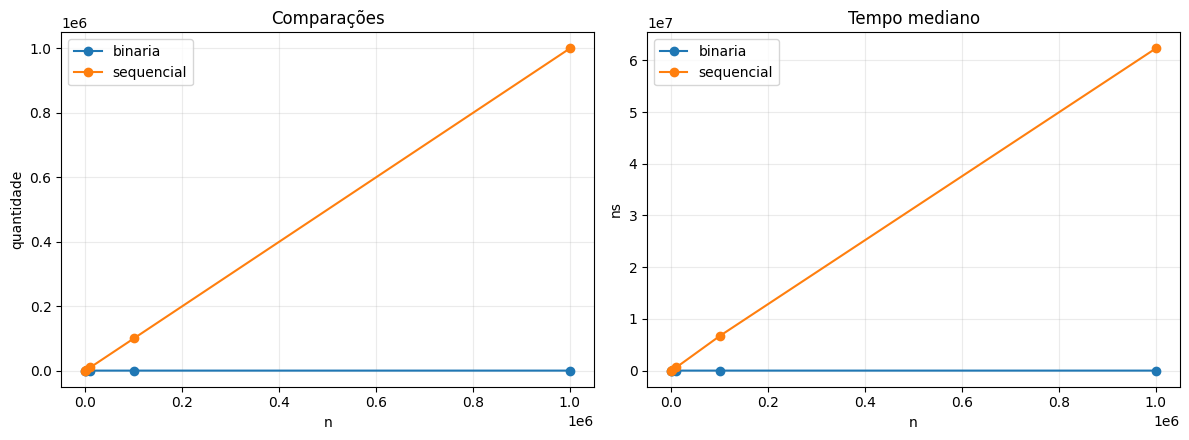

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for nome, grupo in df.groupby("algoritmo"):
    axes[0].plot(grupo["n"], grupo["comparacoes"], marker="o", label=nome)
    axes[1].plot(grupo["n"], grupo["tempo_ns_mediano"], marker="o", label=nome)
axes[0].set(title="Comparações", xlabel="n", ylabel="quantidade")
axes[1].set(title="Tempo mediano", xlabel="n", ylabel="ns")
for ax in axes:
    ax.legend(); ax.grid(alpha=.25)
plt.tight_layout()


## 5.1 Interpretação

1. Qual evidência ficou mais regular: comparações ou tempo?  
   > Escreva aqui.
2. A diferença aumentou com `n`?  
   > Escreva aqui.
3. Algum ruído contradiz `O(n)` ou `O(log n)`?  
   > Escreva aqui.
4. Por que não basta dizer “o menor tempo venceu”?  
   > Escreva aqui.


# Atividade 6 — Então devemos ordenar tudo?

Escolha um cenário:

- **A:** muitas inserções e raríssimas consultas;
- **B:** carga única e milhões de consultas;
- **C:** inserções e consultas contínuas.

Registre:

**Cenário escolhido:**  
> Escreva aqui.

**Estratégia preliminar:**  
> Escreva aqui.

**Justificativa usando operações e custos:**  
> Escreva aqui.


# Síntese de saída

Em até três frases:

> **Por que a busca binária não é apenas uma busca sequencial mais rápida?**

**Resposta:**  
> Escreva aqui.

Complete também:

- A busca sequencial pode ser adequada quando...  
  > Escreva aqui.
- A busca binária exige...  
  > Escreva aqui.
- Ordenar tende a compensar quando...  
  > Escreva aqui.
